In [114]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as cp
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from FallbackGen import FallbackGen
from TDECalculator import TDECalculator
import gc
import json

plt.style.use("plot_style.mplstyle")
plt.rc('text', usetex=True)

In [115]:
adden = "m1_rp5p3"

with open(f"fallback_curves/rel_p_e_{adden}_a0p2.txt", "r") as f:
    rel_p_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_p_t_{adden}_a0p2.txt", "r") as f:
    rel_p_T = {k: np.array(v) for k, v in json.load(f).items()}

adden = "m1_rp6p6"

with open(f"fallback_curves/rel_r_e_{adden}_a0p2.txt", "r") as f:
    rel_r_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_r_t_{adden}_a0p2.txt", "r") as f:
    rel_r_T = {k: np.array(v) for k, v in json.load(f).items()}

adden = "m1_rp6"

with open(f"fallback_curves/rel_sch_e_{adden}.txt", "r") as f:
    rel_sch_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_sch_t_{adden}.txt", "r") as f:
    rel_sch_T = {k: np.array(v) for k, v in json.load(f).items()}

# adden = "m1_rp17"
with open(f"fallback_curves/n_e_{adden}.txt", "r") as f:
    n_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/n_t_{adden}.txt", "r") as f:
    n_T = {k: np.array(v) for k, v in json.load(f).items()}

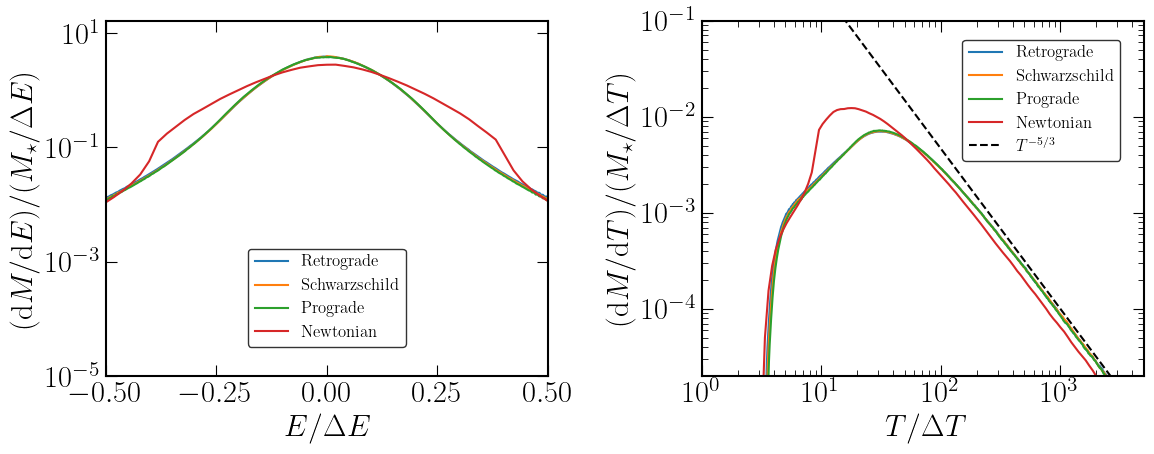

In [116]:
# Build dicts

# Plot
fig, (axE, axT) = plt.subplots(1, 2, figsize=(12, 5))

# Energy
bins_E = np.linspace(-2, 2, 200)
axE.plot(rel_r_E["x"], rel_r_E["y"], label="Retrograde")
axE.plot(rel_sch_E["x"], rel_sch_E["y"], label="Schwarzschild")
axE.plot(rel_p_E["x"], rel_p_E["y"], label="Prograde")
axE.plot(n_E["x"],   n_E["y"],   label="Newtonian")
axE.set_yscale('log')
axE.set_xlabel(r'$E / \Delta E$')
axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')
axE.set_xlim(-0.5,0.5)
axE.set_ylim(1e-5)

axE.legend(
    loc='center',            # the point on the legend box to anchor
    bbox_to_anchor=(0.5, 0.22),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

# Period
axT.plot(rel_r_T["x"], rel_r_T["y"], label="Retrograde")
axT.plot(rel_sch_T["x"], rel_sch_T["y"], label="Schwarzschild")
axT.plot(rel_p_T["x"], rel_p_T["y"], label="Prograde")
axT.plot(n_T["x"],   n_T["y"],   label="Newtonian")
bins_T = np.logspace(0, 6, 200)
axT.plot(bins_T, 10 * bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
axT.set_xscale('log')
axT.set_yscale('log')
axT.set_xlabel(r'$T / \Delta T$')
axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')
axT.set_xlim(1,5000)
axT.set_ylim(2e-5,0.1)
axT.legend(
    loc='upper left',            # the point on the legend box to anchor
    bbox_to_anchor=(0.57, 0.97),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

plt.tight_layout()
plt.show()

In [117]:
with open(f"fallback_curves/rel_sch_e_m1_rp6p2.txt", "r") as f:
    rel_sch_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_sch_t_m1_rp6p2.txt", "r") as f:
    rel_sch_T = {k: np.array(v) for k, v in json.load(f).items()}

adden = "a0p5"
with open(f"fallback_curves/rel_p_e_m1_rp6p2_{adden}.txt", "r") as f:
    rel_0p5_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_p_t_m1_rp6p2_{adden}.txt", "r") as f:
    rel_0p5_T = {k: np.array(v) for k, v in json.load(f).items()}

with open(f"fallback_curves/rel_r_e_m1_rp6p2_{adden}.txt", "r") as f:
    rel_m0p5_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_r_t_m1_rp6p2_{adden}.txt", "r") as f:
    rel_m0p5_T = {k: np.array(v) for k, v in json.load(f).items()}

adden = "a0p99"
with open(f"fallback_curves/rel_p_e_m1_rp6p2_{adden}.txt", "r") as f:
    rel_0p99_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_p_t_m1_rp6p2_{adden}.txt", "r") as f:
    rel_0p99_T = {k: np.array(v) for k, v in json.load(f).items()}

with open(f"fallback_curves/rel_r_e_m1_rp6p2_{adden}.txt", "r") as f:
    rel_m0p99_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_r_t_m1_rp6p2_{adden}.txt", "r") as f:
    rel_m0p99_T = {k: np.array(v) for k, v in json.load(f).items()}


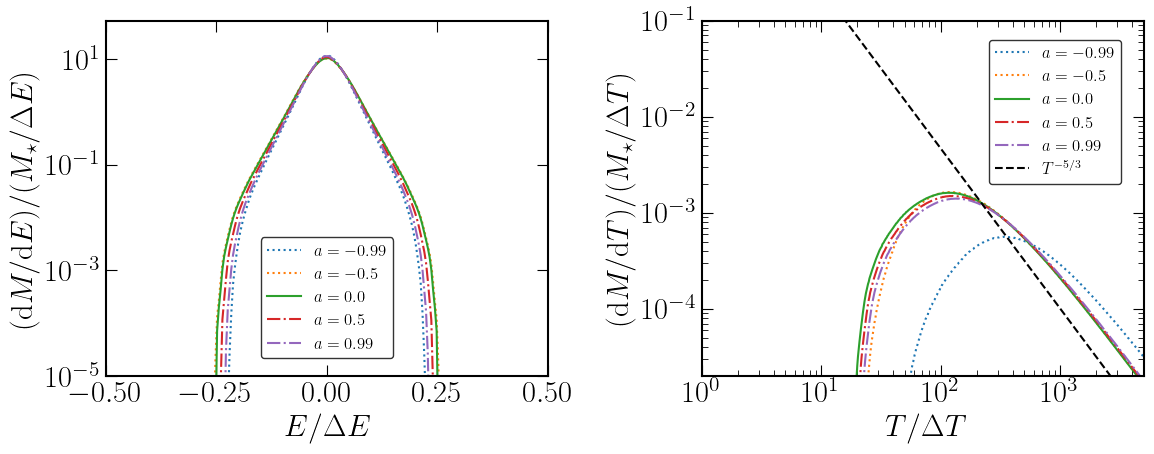

In [118]:
# Build dicts

# Plot
fig, (axE, axT) = plt.subplots(1, 2, figsize=(12, 5))

# Energy
bins_E = np.linspace(-2, 2, 200)
axE.plot(rel_m0p99_E["x"],   rel_m0p99_E["y"],   label="$a=-0.99$", linestyle=":")
axE.plot(rel_m0p5_E["x"], rel_m0p5_E["y"], label="$a=-0.5$", linestyle=":")
axE.plot(rel_sch_E["x"], rel_sch_E["y"], label="$a=0.0$")
axE.plot(rel_0p5_E["x"], rel_0p5_E["y"], label="$a=0.5$", linestyle="-.")
axE.plot(rel_0p99_E["x"],   rel_0p99_E["y"],   label="$a=0.99$", linestyle="-.")
axE.set_yscale('log')
axE.set_xlabel(r'$E / \Delta E$')
axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')
axE.set_xlim(-0.5,0.5)
axE.set_ylim(1e-5)

axE.legend(
    loc='center',            # the point on the legend box to anchor
    bbox_to_anchor=(0.5, 0.22),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

# Period
axT.plot(rel_m0p99_T["x"],   rel_m0p99_T["y"],   label="$a=-0.99$", linestyle=":")
axT.plot(rel_m0p5_T["x"], rel_m0p5_T["y"], label="$a=-0.5$", linestyle=":")
axT.plot(rel_sch_T["x"], rel_sch_T["y"], label="$a=0.0$")
axT.plot(rel_0p5_T["x"], rel_0p5_T["y"], label="$a=0.5$", linestyle="-.")
axT.plot(rel_0p99_T["x"],   rel_0p99_T["y"],   label="$a=0.99$", linestyle="-.")
bins_T = np.logspace(0, 6, 200)
axT.plot(bins_T, 10 * bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
axT.set_xscale('log')
axT.set_yscale('log')
axT.set_xlabel(r'$T / \Delta T$')
axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')
axT.set_xlim(1,5000)
axT.set_ylim(2e-5,0.1)
axT.legend(
    loc='upper left',            # the point on the legend box to anchor
    bbox_to_anchor=(0.63, 0.97),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

plt.tight_layout()
plt.show()

In [119]:
adden = "m1_rp4p5_a0p2"

with open(f"fallback_curves/rel_p_e_{adden}.txt", "r") as f:
    rel_rp7p5_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_p_t_{adden}.txt", "r") as f:
    rel_rp7p5_T = {k: np.array(v) for k, v in json.load(f).items()}

adden = "m1_rp9p3_a0p2"

with open(f"fallback_curves/rel_p_e_{adden}.txt", "r") as f:
    rel_rp15_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_p_t_{adden}.txt", "r") as f:
    rel_rp15_T = {k: np.array(v) for k, v in json.load(f).items()}

adden = "m1_rp14p2_a0p2"

with open(f"fallback_curves/rel_p_e_{adden}.txt", "r") as f:
    rel_rp17_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_p_t_{adden}.txt", "r") as f:
    rel_rp17_T = {k: np.array(v) for k, v in json.load(f).items()}

adden = "m1_rp19_a0p2"

with open(f"fallback_curves/rel_p_e_{adden}.txt", "r") as f:
    rel_rp19_E = {k: np.array(v) for k, v in json.load(f).items()}
with open(f"fallback_curves/rel_p_t_{adden}.txt", "r") as f:
    rel_rp19_T = {k: np.array(v) for k, v in json.load(f).items()}

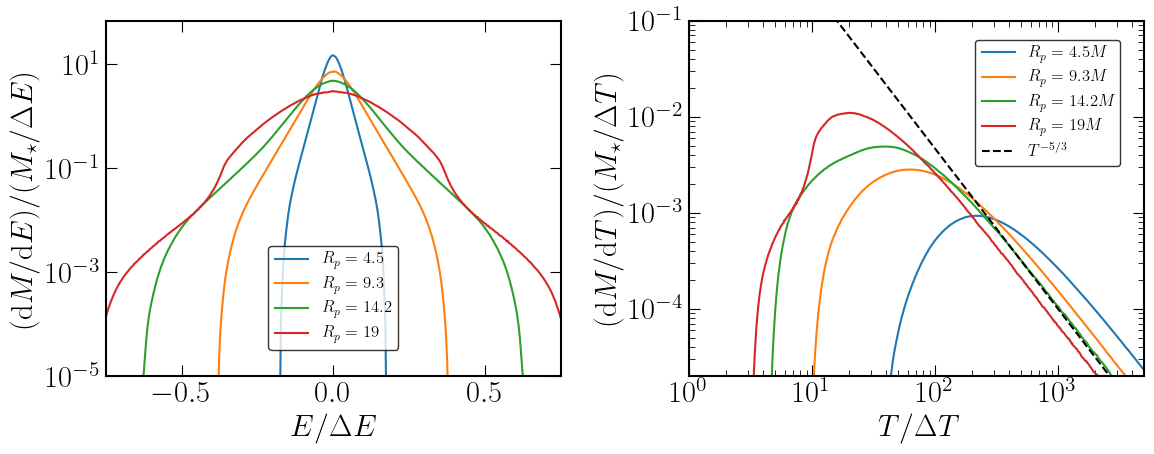

In [120]:
# Build dicts

# Plot
fig, (axE, axT) = plt.subplots(1, 2, figsize=(12, 5))

# Energy
bins_E = np.linspace(-2, 2, 200)
axE.plot(rel_rp7p5_E["x"], rel_rp7p5_E["y"], label="$R_{p}=5.3$")
axE.plot(rel_rp15_E["x"], rel_rp15_E["y"], label="$R_{p}=9.9$")
axE.plot(rel_rp17_E["x"], rel_rp17_E["y"], label="$R_{p}=14.4$")
axE.plot(rel_rp19_E["x"],   rel_rp19_E["y"],   label="$R_{p}=19$")
axE.set_yscale('log')
axE.set_xlabel(r'$E / \Delta E$')
axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')
axE.set_xlim(-0.75,0.75)
axE.set_ylim(1e-5)

axE.legend(
    loc='center',            # the point on the legend box to anchor
    bbox_to_anchor=(0.5, 0.22),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

# Period
axT.plot(rel_rp7p5_T["x"], rel_rp7p5_T["y"], label="$R_{p}=5.3M$")
axT.plot(rel_rp15_T["x"], rel_rp15_T["y"], label="$R_{p}=9.9M$")
axT.plot(rel_rp17_T["x"], rel_rp17_T["y"], label="$R_{p}=14.4M$")
axT.plot(rel_rp19_T["x"],   rel_rp19_T["y"],   label="$R_{p}=19M$")
bins_T = np.logspace(0, 6, 200)
axT.plot(bins_T, 10 * bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
axT.set_xscale('log')
axT.set_yscale('log')
axT.set_xlabel(r'$T / \Delta T$')
axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')
axT.set_xlim(1,5000)
axT.set_ylim(2e-5,0.1)
axT.legend(
    loc='upper left',            # the point on the legend box to anchor
    bbox_to_anchor=(0.61, 0.97),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

plt.tight_layout()
plt.show()